Development of a Machine Learning Regression Model for Predicting Molecular Retention Time Using Molecular

Objectives
To understand the relationship between molecular descriptors and chromatographic retention time.
To prepare and preprocess a molecular descriptor dataset for machine learning.
To use molecular descriptors as input features (X) and retention time (rt) as the target variable (y).
To develop a Linear Regression baseline model for retention-time prediction.
To evaluate the model using MAE, RMSE, and R².
To visualize and compare actual vs. predicted retention times.
To assess whether more advanced nonlinear models can improve prediction performance.
Expected Outcome

A trained and evaluated regression model capable of predicting the retention time of molecules from their molecular descriptors, together with quantitative performance metrics and an Actual vs. Predicted plot.

In [ ]:
!pip install -q gdown

file_id = "1zwiF-KBtUbMQMBKNkmV8INVev1_W_11Z"

!gdown "https://drive.google.com/uc?id=1zwiF-KBtUbMQMBKNkmV8INVev1_W_11Z" -O descriptors.csv

Downloading...
From (original): https://drive.google.com/uc?id=1zwiF-KBtUbMQMBKNkmV8INVev1_W_11Z
From (redirected): https://drive.google.com/uc?id=1zwiF-KBtUbMQMBKNkmV8INVev1_W_11Z&confirm=t&uuid=9f7f284e-b361-4d65-81fb-39a90f1504e9
To: /content/descriptors.csv
100% 134M/134M [00:03<00:00, 37.3MB/s]


In [ ]:
import pandas as pd

df = pd.read_csv("descriptors.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (77901, 124)


,MaxEStateIndex,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,...,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,rt
0,12.990628,-0.335181,12.990628,0.035905,0.760602,414.333,389.133,413.127297,148,0,...,0,8,4,0,2,2,3,2.9109,105.3190,687.8
1,12.609649,-3.521975,12.609649,0.030555,0.702317,369.487,342.271,369.172227,140,0,...,2,8,7,0,1,1,2,1.2851,97.7354,590.7
2,11.164259,-0.177407,11.164259,0.137593,0.610213,161.160,154.104,161.047678,60,0,...,2,3,0,0,0,0,2,1.2337,46.2335,583.6
3,11.161791,-0.252097,11.161791,0.221895,0.900805,260.337,240.177,260.152478,102,0,...,1,4,3,0,2,2,3,1.8035,73.0347,579.0
4,11.266054,-0.615607,11.266054,0.048741,0.656633,279.340,258.172,279.158292,110,0,...,4,6,5,0,0,0,2,0.9840,78.1769,603.1


In [ ]:
# Basic information about the dataset

print("=" * 60)
print("DATASET INSPECTION")
print("=" * 60)

print("\n1. Dataset dimensions:")
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

print("\n2. Column names:")
print(df.columns.tolist())

print("\n3. Data types:")
print(df.dtypes.value_counts())

print("\n4. First 5 rows:")
display(df.head())

print("\n5. Last 5 rows:")
display(df.tail())

DATASET INSPECTION

1. Dataset dimensions:
Rows    : 77901
Columns : 124

2. Column names:
['MaxEStateIndex', 'MinEStateIndex', 'MaxAbsEStateIndex', 'MinAbsEStateIndex', 'qed', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'NumRadicalElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_

,MaxEStateIndex,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,...,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,rt
0,12.990628,-0.335181,12.990628,0.035905,0.760602,414.333,389.133,413.127297,148,0,...,0,8,4,0,2,2,3,2.9109,105.3190,687.8
1,12.609649,-3.521975,12.609649,0.030555,0.702317,369.487,342.271,369.172227,140,0,...,2,8,7,0,1,1,2,1.2851,97.7354,590.7
2,11.164259,-0.177407,11.164259,0.137593,0.610213,161.160,154.104,161.047678,60,0,...,2,3,0,0,0,0,2,1.2337,46.2335,583.6
3,11.161791,-0.252097,11.161791,0.221895,0.900805,260.337,240.177,260.152478,102,0,...,1,4,3,0,2,2,3,1.8035,73.0347,579.0
4,11.266054,-0.615607,11.266054,0.048741,0.656633,279.340,258.172,279.158292,110,0,...,4,6,5,0,0,0,2,0.9840,78.1769,603.1



5. Last 5 rows:


,MaxEStateIndex,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,...,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,rt
77896,13.007487,-3.875168,13.007487,0.088259,0.376539,499.589,470.357,499.177707,186,0,...,2,10,11,0,0,0,3,5.10012,135.1192,946.4
77897,13.419078,-3.804433,13.419078,0.073874,0.707316,401.460,377.268,401.142070,150,0,...,1,10,6,0,2,2,3,0.64550,95.2845,653.1
77898,12.923979,-3.564135,12.923979,0.170980,0.745031,383.470,358.270,383.151492,144,0,...,1,9,5,0,2,2,3,0.42472,95.4465,648.2
77899,13.001197,-3.578462,13.001197,0.187554,0.835872,415.515,390.315,415.156577,154,0,...,1,8,3,0,2,2,4,2.60924,110.3695,783.9
77900,12.083727,-0.117339,12.083727,0.005492,0.784622,244.294,228.166,244.121178,94,0,...,1,4,3,0,2,2,3,0.43350,66.7157,603.7


In [ ]:
# Check data quality

print("=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)

# 1. Missing values
print("\n1. Missing values:")
missing = df.isnull().sum()

print(missing[missing > 0].sort_values(ascending=False))

# 2. Total missing values
print("\nTotal missing values:", df.isnull().sum().sum())

# 3. Duplicate rows
print("\n2. Duplicate rows:", df.duplicated().sum())

# 4. Check target variable
print("\n3. Retention time (rt) information:")
print(df["rt"].describe())

DATA QUALITY CHECK

1. Missing values:
Series([], dtype: int64)

Total missing values: 0

2. Duplicate rows: 0

3. Retention time (rt) information:
count    77901.000000
mean       808.600919
std        174.701901
min        175.900000
25%        668.900000
50%        779.800000
75%        917.000000
max       1471.700000
Name: rt, dtype: float64


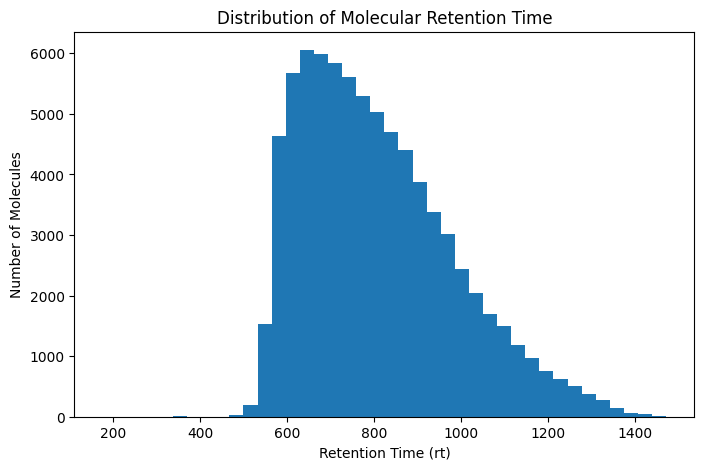

In [ ]:
import matplotlib.pyplot as plt

# Distribution of retention time
plt.figure(figsize=(8, 5))

plt.hist(df["rt"], bins=40)

plt.xlabel("Retention Time (rt)")
plt.ylabel("Number of Molecules")
plt.title("Distribution of Molecular Retention Time")

plt.show()

In [ ]:
# Separate input features (X) and target (y)

target = "rt"

X = df.drop(columns=[target])
y = df[target]

# Remove constant descriptors
constant_columns = X.columns[X.nunique() <= 1]

print("Constant descriptors found:", len(constant_columns))

X = X.drop(columns=constant_columns)

print("Number of molecules:", X.shape[0])
print("Number of descriptors used:", X.shape[1])

Constant descriptors found: 3
Number of molecules: 77901
Number of descriptors used: 120


In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])
print("Training features:", X_train.shape[1])
print("Testing features :", X_test.shape[1])

Training samples: 62320
Testing samples : 15581
Training features: 120
Testing features : 120


In [ ]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [ ]:
# Predict retention time for the test set

y_pred = linear_model.predict(X_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

# Show first 10 actual vs predicted values
results = pd.DataFrame({
    "Actual_rt": y_test.values,
    "Predicted_rt": y_pred
})

display(results.head(10))

Predictions generated successfully.
Number of predictions: 15581


,Actual_rt,Predicted_rt
0,585.4,620.099731
1,804.2,928.437303
2,865.8,766.000681
3,759.0,909.348365
4,564.5,571.175151
5,1064.9,1107.578483
6,691.1,688.005212
7,618.2,665.903773
8,876.3,879.439033
9,623.0,671.157804


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=" * 50)
print("LINEAR REGRESSION MODEL PERFORMANCE")
print("=" * 50)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

LINEAR REGRESSION MODEL PERFORMANCE
MAE  : 85.384
RMSE : 112.965
R²   : 0.584


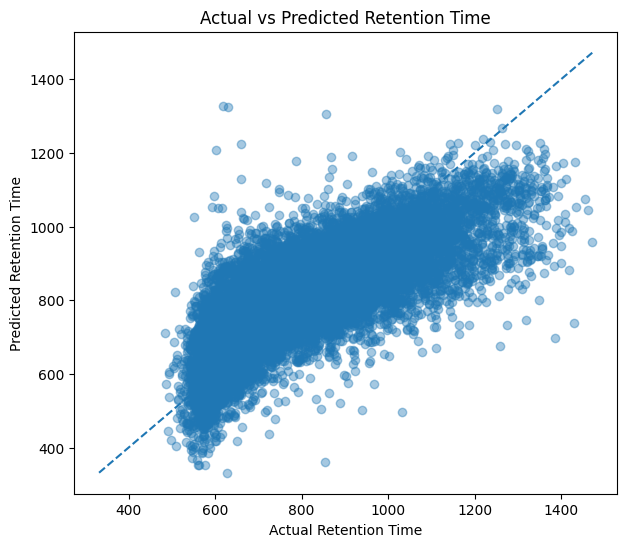

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred, alpha=0.4)

# Perfect prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Retention Time")
plt.ylabel("Predicted Retention Time")
plt.title("Actual vs Predicted Retention Time")

plt.show()

Interpretation of the plot

The points show a clear positive relationship, but they are widely scattered around the perfect-prediction line.

This explains why:

R² = 0.584 → moderate predictive performance
MAE = 85.384 → fairly large average error
The model tends to underpredict some high RT values and has substantial scatter.

So Linear Regression is useful as our baseline, but it is not our final model.

**Step 11 — Try a Nonlinear Model: Random Forest**
Retention time can have nonlinear relationships with molecular descriptors. Random Forest can capture these relationships better than Linear Regression.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


Why Random Forest?

It builds many decision trees and combines their predictions. This allows it to capture complex, nonlinear relationships between molecular descriptors and retention time.

After this, we'll evaluate Random Forest using the same MAE, RMSE and R² metrics, so we can make a fair comparison with Linear Regression.